In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
# define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [5]:
def calculate_BMI(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)

    return state


In [ ]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_BMI', calculate_BMI)

# add edges to your graph
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', END)

#compile the graph
workflow = graph.compile()

In [8]:
#execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


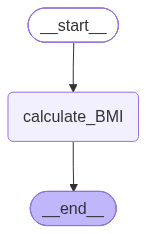

In [9]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())